## Análisis y Procesamiento de Señales
# **Trabajo Semanal n°2: Modelizando un ADC**
#### Hecho por Tomás Ladiani [git](https://github.com/TLadiani)

## **Introducción: Fundamentos teóricos de la simulación de un ADC**
En esta tarea, el objetivo es modelar el proceso completo de digitalización, el cual consta de dos discretizaciones fundamentales:
- *Muestreo (Discretización en el tiempo)*: La señal continua se evalúa a intervalos regulares definidos por la frecuencia de muestreo $f_S = 1000$ Hz. Esto define el ancho de banda analizable (hasta la frecuencia de Nyquist, $f_S/2 = 500$ Hz).
- *Cuantización (Discretización en amplitud)*: Los valores analógicos se mapean a un conjunto finito de $2^B$ niveles discretos dentro del rango a fondo de escala $\pm V_F$. La distancia entre estos niveles es el paso de cuantización $q = \frac{2V_F}{2^B}$.

**El modelo de Ruido (Cuantización y Aditivo)**: El proceso de cuantización no es ideal, introduce un error irreversible. Bajo ciertas condiciones (señal compleja, sin recortes severos), este error de cuantización $e_q$ se modela como un ruido blanco de distribución uniforme entre $-q/2$ y $q/2$, cuya potencia (o varianza) teórica es: $P_q = \frac{q^2}{12}$. En la realidad, la señal que ingresa al ADC ($s_R$) ya viene contaminada por ruido térmico o interferencias analógicas ($n$). La consigna plantea modelar este ruido analógico como Gaussiano y relacionar su potencia $P_n$ directamente con la del ruido de cuantización mediante el factor de escala $k_n$:
  $$P_n = k_n \cdot P_q$$
  Cuando $k_n = 1$, la potencia del ruido analógico de entrada es exactamente igual a la potencia del ruido digital generado por el propio ADC.

Librerías y Definiciones:

In [20]:
#%% Librerías
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import square, unit_impulse
from scipy.fft import fft, fftshift, fftfreq

#%%Definiciones
N=1000
fs = 1000.0
f0 = fs/N
Vr = 2
B = 4
k = 1
q = (2*Vr)/(2**B) 
Pq = (q**2)/12
Pn = k * Pq

Funciones usadas:

In [21]:
#%% Funciones
def gen_sin(vmax=1.0, dc=0.0, ff=1.0, ph=0.0, nn=1000, fs=1000.0):
    """
    Genera una señal senoidal en tiempo discreto.

    Parámetros:
    vmax: Amplitud pico de la señal.
    dc: Nivel de continua (valor medio).
    ff: Frecuencia fundamental de la señal (Hz).
    ph: Fase inicial de la señal (radianes).
    nn: Número de muestras a generar.
    fs: Frecuencia de muestreo (Hz).

    Retorna:
    tt: Vector de tiempo discreto.
    xx: Vector de amplitud de la señal generada.
    """
    ts = 1.0 / fs
    tt = np.arange(0, nn * ts, ts)
    tt = tt[:nn] 
    xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc
    
    return tt, xx

def gen_ruido(varianza=0.1, distribucion='normal', nn=1000, fs=1000.0):
    """
    Genera una secuencia de ruido aleatorio con valor medio nulo.

    Parámetros:
    varianza: Varianza del ruido (equivalente a la potencia media en W si la carga es 1 ohm).
    distribucion: Tipo de distribución ('normal' o 'uniforme').
    nn: Número de muestras a generar.
    fs: Frecuencia de muestreo (Hz).

    Retorna:
    tt: Vector de tiempo discreto.
    xx: Vector de amplitud del ruido generado.
    """
    ts = 1.0 / fs
    tt = np.arange(0, nn * ts, ts)
    tt = tt[:nn]
    
    if distribucion == 'normal':
        # La desviación estándar es la raíz cuadrada de la varianza
        desvio_estandar = np.sqrt(varianza)
        xx = np.random.normal(loc=0.0, scale=desvio_estandar, size=nn)
        
    elif distribucion == 'uniforme':
        # Para una distribución uniforme entre [-a, a], la varianza es (a^2)/3
        # Despejando 'a' para obtener la varianza deseada: a = sqrt(3 * varianza)
        a = np.sqrt(3 * varianza)
        xx = np.random.uniform(low=-a, high=a, size=nn)
        
    else:
        raise ValueError("La distribución debe ser 'normal' o 'uniforme'.")
        
    return tt, xx

def cuantizar(xx, bits=4, v_min=-1.0, v_max=1.0):
    """
    Aplica cuantización uniforme de B bits a una señal mediante np.around.
    """
    niveles = 2 ** bits
    q = (v_max - v_min) / niveles
    
    # 1. Saturación (saturar valores fuera del rango dinámico del ADC)
    xx_sat = np.clip(xx, v_min, v_max - q)
    
    # 2. Asignación al nivel discreto más cercano usando np.around
    indices = np.around((xx_sat - v_min) / q)
    
    # 3. Reconstrucción al valor analógico cuantizado
    xx_q = v_min + indices * q
    
    # 4. Error o ruido de cuantización
    error_q = xx_q - xx
    
    return xx_q, error_q, q

def graficar_histograma_error(error_q, q, bits):
    """
    Grafica el histograma del ruido de cuantización y lo compara 
    con la distribución de probabilidad uniforme teórica.
    """
    plt.figure(figsize=(8, 4))
    
    # Histograma del error (normalizado con density=True para obtener densidad de probabilidad)
    plt.hist(error_q, bins=10, density=True, alpha=0.7, color='blue', edgecolor='black', label='Histograma')
    
    # PDF teórica: Distribución uniforme entre -q/2 y q/2
    # La amplitud de la PDF debe ser 1/q para que el área bajo la curva sea 1
    densidad_proba_x = [-q, -q/2, -q/2, q/2, q/2, q]
    densidad_proba_y = [0, 0, 1/q, 1/q, 0, 0]
    
    plt.plot(densidad_proba_x, densidad_proba_y, color='red', linestyle='--', linewidth=2, label='función densidad de probabilidad Uniforme Teórica')
    
    plt.title(f"Histograma del Ruido de Cuantización (B = {bits} bits)")
    plt.xlabel("Amplitud del Error [V]")
    plt.ylabel("Densidad de Probabilidad")
    
    # Ajuste de los ejes para enmarcar correctamente la distribución
    plt.xlim([-2*q/3, 2*q/3])
    
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

## **Ejercicio 1**:
Modelizar un ADC de 4 bits y $k_n$ = 1 para una señal senoidal+ruido.

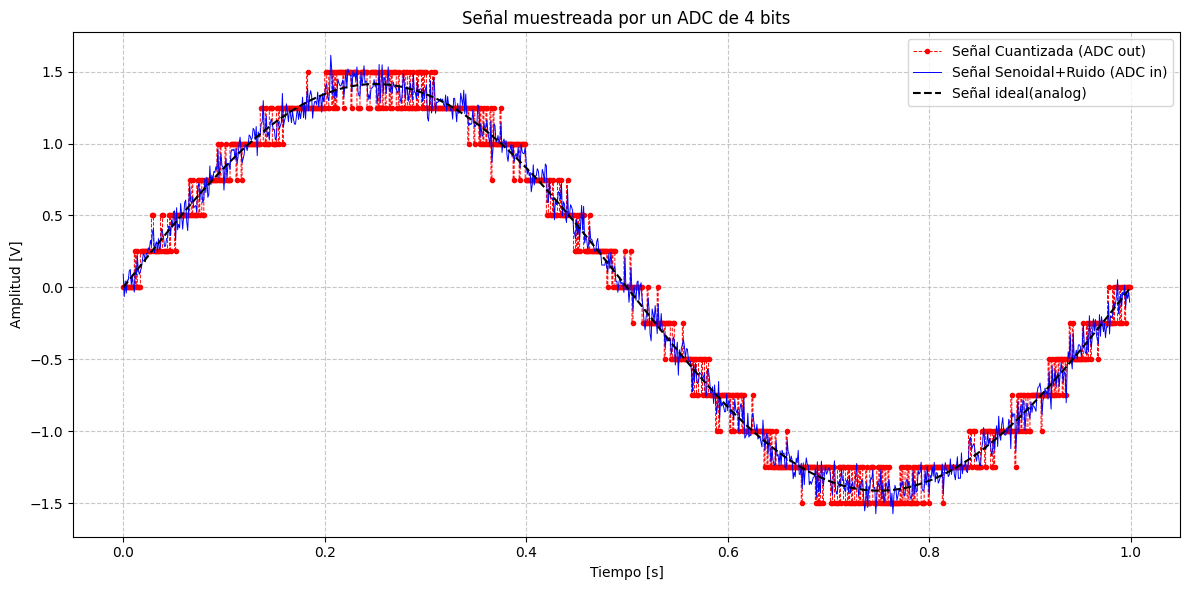

In [22]:
#Señales (tiempo)
ttr,ruido = gen_ruido(varianza=Pn, nn=N, fs=fs)
tts,senoidal = gen_sin(vmax= np.sqrt(2), ff=1, nn=N, fs=1000) #varianza unitaria
Sr = senoidal + ruido
Sr_cuantizada, error_q, q = cuantizar(Sr, 4, -2, 2)

 #Grafico conjunto de las señales respecto del tiempo
plt.figure(figsize=(12, 6))
plt.step(tts, Sr_cuantizada, color = "red", linewidth=0.7, linestyle='--',marker='.', label='Señal Cuantizada (ADC out)') #señal cuantizada
plt.plot(tts, Sr, color="blue", linewidth=0.7, label='Señal Senoidal+Ruido (ADC in)') #Señal senoidal+ruido
plt.plot(tts, senoidal, color="black", linestyle='--', label='Señal ideal(analog)') #señal senoidal ideal

plt.grid(True, linestyle='--', alpha=0.7)
plt.title("Señal muestreada por un ADC de 4 bits")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.legend()
plt.tight_layout()
plt.show()


#### **Análisis Temporal**
- *Discretización visible*: La señal analógica de entrada (azul), que ya presenta fluctuaciones aleatorias debido al ruido Gaussiano aditivo, es forzada por el ADC a tomar valores dentro de un conjunto finito y discreto de tensiones (rojo).
- *Efecto de la baja resolución*: Al utilizar un conversor de 4 bits en un rango de $\pm 2$ V, el sistema solo dispone de 16 niveles de cuantización posibles. Esto define un paso de cuantización grande (q = 0.25 V). Debido a esta baja resolución, el error introducido es severo y los "saltos" o escalones son muy pronunciados. Además, se observa que en los picos de la senoidal, donde la señal ideal (en negro) varía lentamente, el ruido analógico inyectado provoca que la señal cuantizada salte erráticamente entre dos niveles adyacentes.

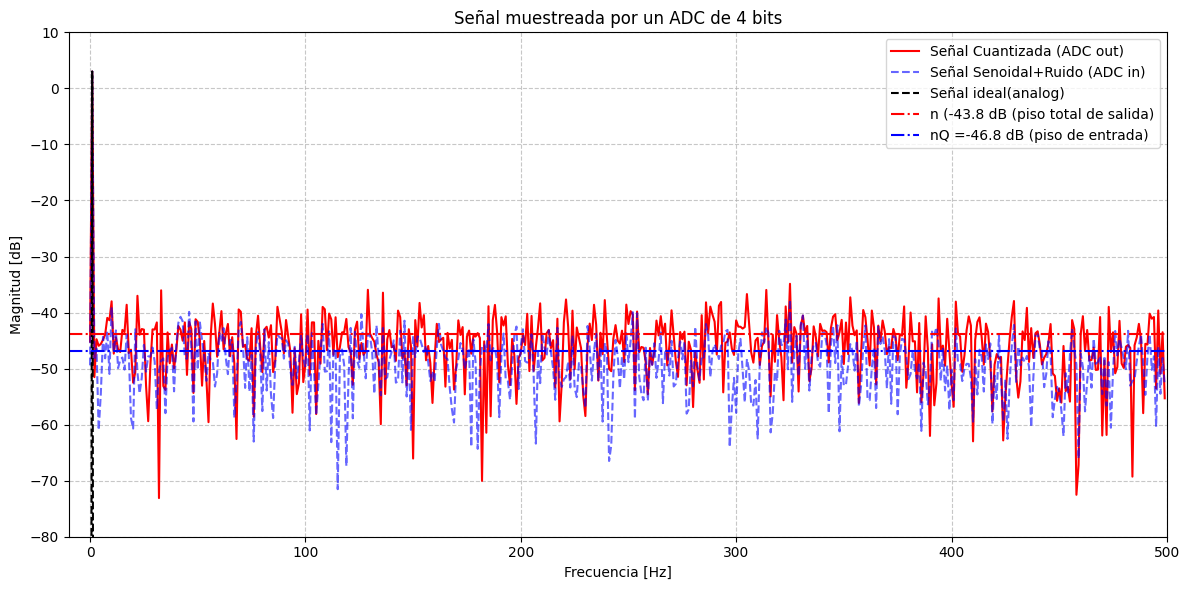

In [23]:
#Espectro de las señales (frecuencia)
 #eje de frecuencias
limite = N // 2
frecs_pos = fftfreq(N, 1/fs)[:limite]
eps = 1e-12 # Constante para evitar log(0)

 #Señal Ideal (Senoidal)
X_ideal = fft(senoidal) / N
magn_ideal = np.abs(X_ideal)[:limite]
magn_ideal[1:] = magn_ideal[1:] * 2
espectro_ideal_db = 20 * np.log10(magn_ideal + eps)

 #Señal ADC in (Senoidal + Ruido)
X_in = fft(Sr) / N
magn_in = np.abs(X_in)[:limite]
magn_in[1:] = magn_in[1:] * 2
espectro_in_db = 20 * np.log10(magn_in + eps)

 #Señal ADC out (Cuantizada)
X_out = fft(Sr_cuantizada) / N
magn_out = np.abs(X_out)[:limite]
magn_out[1:] = magn_out[1:] * 2
espectro_out_db = 20 * np.log10(magn_out + eps)

 #Cálculo de los pisos de ruido
 #Piso analógico (n)
piso_n_db = 10 * np.log10(4 * Pn / N)
 #Piso digital (nQ)
piso_q_db = 10 * np.log10(4 * Pq / N)
 #Piso total esperado a la salida (analógico + cuantización)
piso_total_db = 10 * np.log10(4 * (Pn + Pq) / N)

 #Gráfico
plt.figure(figsize=(12, 6))

 #Espectros en db
plt.plot(frecs_pos, espectro_out_db, color="red", label="Señal Cuantizada (ADC out)")
plt.plot(frecs_pos, espectro_in_db, color="blue", linestyle='--', alpha=0.6, label="Señal Senoidal+Ruido (ADC in)")
plt.plot(frecs_pos, espectro_ideal_db, color="black", linestyle='--', label="Señal ideal(analog)")
 #Pisos de ruido

plt.axhline(piso_total_db, color="red", linestyle="-.", linewidth=1.5, label=f"n ({piso_total_db:.1f} dB (piso total de salida)")
plt.axhline(piso_n_db, color="blue", linestyle="-.", linewidth=1.5, label=f"nQ ={piso_n_db:.1f} dB (piso de entrada)")
#plt.axhline(piso_q_db, color="yellow", linestyle=":", linewidth=2.5, label=f"nQ ={piso_q_db:.1f} dB (piso digital)")

plt.grid(True, linestyle='--', alpha=0.7)
plt.title("Señal muestreada por un ADC de 4 bits")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.xlim([-10, fs/2]) # Limitar el eje X hasta la frecuencia de Nyquist
plt.ylim([-80, 10]) # Límite inferior y superior en dB
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

#### **Análisis Espectral y Pisos de Ruido**
- *Diferenciación de espectros*: El espectro de la señal senoidal ideal (línea punteada negra) presenta la delta de Dirac esperada en la frecuencia fundamental (1 Hz), con un piso numérico residual extremadamente bajo (de unos -250dB limitado por la precisión de la computadora). En contraste, la señal que ingresa al ADC (azul) exhibe un piso de ruido analógico plano y elevado, característico del ruido blanco inyectado.
- *Impacto de la Cuantización*: La señal a la salida del ADC (rojo) muestra un piso de ruido aún mayor. Esto ocurre porque al ruido analógico original se le ha sumado de forma incorrelada el ruido generado por el propio proceso de cuantización.

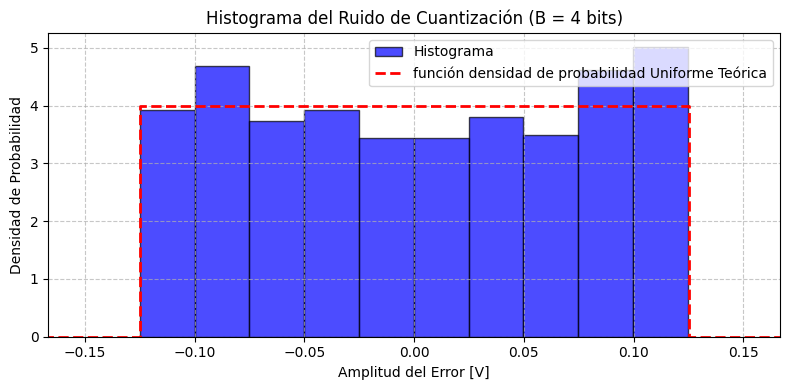

In [24]:
#Histograma
graficar_histograma_error(error_q, q, 4)

#### **Análisis Estadístico (Histograma)**
- *Distribución del Error*: El histograma azul representa empíricamente cómo se distribuye el error real medido ($e_q = s_{cuantizada} - s_{in}$). Para un ADC ideal procesando una señal compleja sin ruido analógico, esperaríamos que las barras azules llenen uniformemente el recuadro rojo definido por la función de densidad de probabilidad uniforme teórica entre -q/2 y q/2.
- *Efecto del Ruido Aditivo*: Al haber inyectado un ruido Gaussiano en la entrada cuya potencia es comparable a la del ruido de cuantización ($P_n = P_q$), el proceso estadístico se altera. El error resultante es la combinación de ambas variables aleatorias. Como resultado empírico, se observa que la distribución final tiende a "desparramarse", perdiendo la forma de caja perfectamente rectangular y presentando colas que pueden exceder ligeramente los límites teóricos del paso de cuantización, evidenciando la interacción entre la interferencia analógica y la discretización digital.

## Ejercicio 2:
Analizar para una de las configuraciones B = {4, 8 y 16}, $ k_n = {1/10 , 1, 10}$

In [25]:
#Función para analizar las configuraciones.
def analizar_adc(bits, kn, N=1000, fs=1000.0, Vr=2.0):
    """
    Simula y analiza el comportamiento de un ADC para una configuración dada
    de resolución (bits) y factor de ruido analógico (kn).
    """
    # 1. Parámetros del conversor y ruido
    q = (2 * Vr) / (2**bits)
    Pq = (q**2) / 12
    Pn = kn * Pq

    # 2. Generación de señales temporales
    tts, senoidal = gen_sin(vmax=np.sqrt(2), ff=1.0, nn=N, fs=fs)
    ttr, ruido = gen_ruido(varianza=Pn, nn=N, fs=fs)
    Sr = senoidal + ruido

    # 3. Cuantización
    Sr_cuantizada, error_q, delta = cuantizar(Sr, bits=bits, v_min=-Vr, v_max=Vr)

    # 4. Cálculo espectral (FFT unilateral en dB)
    limite = N // 2
    frecs_pos = fftfreq(N, 1 / fs)[:limite]
    eps = 1e-12

    # Espectro ADC in
    X_in = fft(Sr) / N
    magn_in = np.abs(X_in)[:limite]
    magn_in[1:] = magn_in[1:] * 2
    espectro_in_db = 20 * np.log10(magn_in + eps)

    # Espectro ADC out
    X_out = fft(Sr_cuantizada) / N
    magn_out = np.abs(X_out)[:limite]
    magn_out[1:] = magn_out[1:] * 2
    espectro_out_db = 20 * np.log10(magn_out + eps)

    # 5. Pisos teóricos
    piso_n_db = 10 * np.log10(4 * Pn / N)
    piso_q_db = 10 * np.log10(4 * Pq / N)
    piso_total_db = 10 * np.log10(4 * (Pn + Pq) / N)

    # 6. Gráfica espectral
    plt.figure(figsize=(10, 4))
    plt.plot(
        frecs_pos,
        espectro_out_db,
        color="red",
        label="Señal Cuantizada (ADC out)",
    )
    plt.plot(
        frecs_pos,
        espectro_in_db,
        color="blue",
        alpha=0.5,
        label="Señal Senoidal+Ruido (ADC in)",
    )

    plt.axhline(
        piso_n_db,
        color="blue",
        linestyle=":",
        linewidth=1.8,
        label=f"Piso n ({piso_n_db:.1f} dB)",
    )
    plt.axhline(
        piso_q_db,
        color="black",
        linestyle="--",
        linewidth=1.8,
        label=f"Piso nQ ({piso_q_db:.1f} dB)",
    )
    plt.axhline(
        piso_total_db,
        color="magenta",
        linestyle="-.",
        linewidth=1.5,
        label=f"Piso Total Esperado ({piso_total_db:.1f} dB)",
    )

    plt.title(f"Espectro ADC | B = {bits} bits, kn = {kn}")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Magnitud [dB]")
    plt.xlim([-5, fs / 2])
    plt.ylim([min(piso_total_db - 20, -140), 10])
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()

    # 7. Histograma del error
    graficar_histograma_error(error_q, delta, bits)

### Para 8 bits

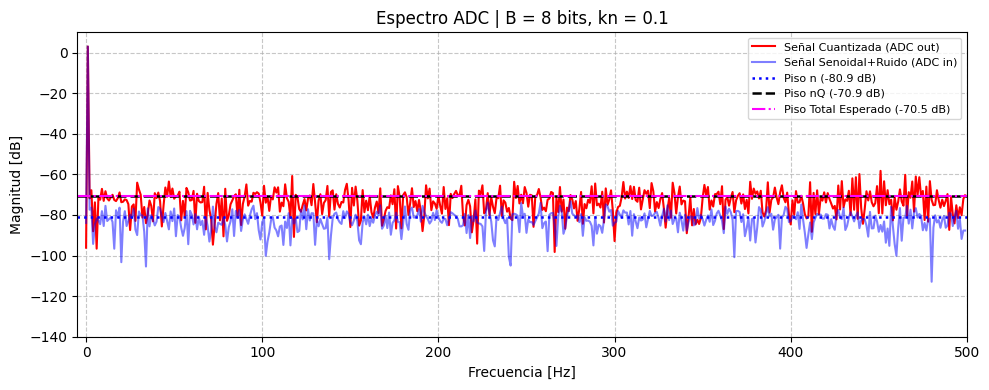

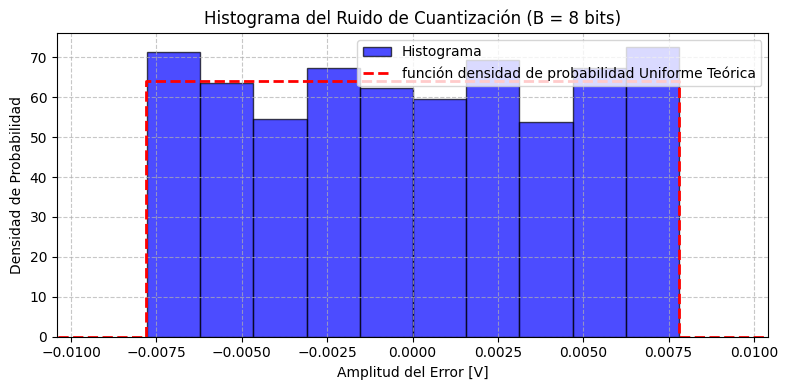

In [26]:
analizar_adc(bits=8, kn=0.1)

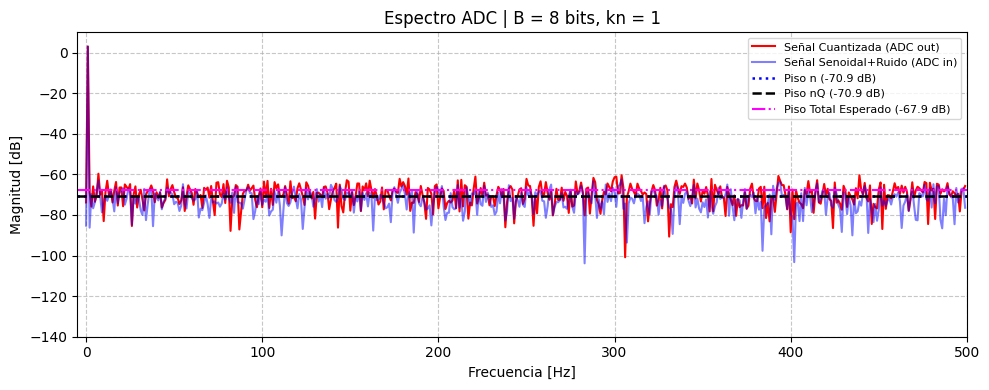

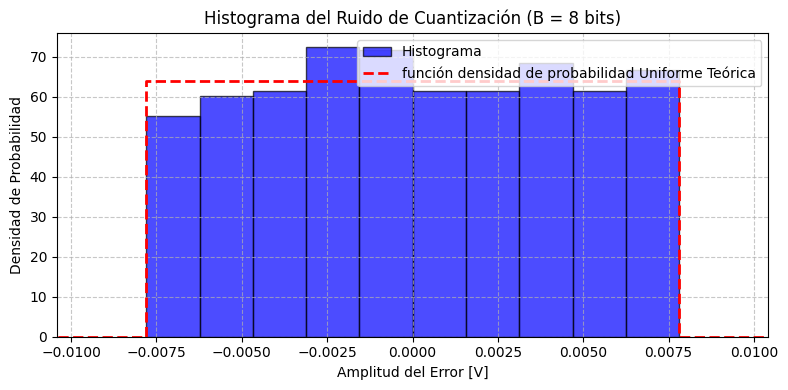

In [27]:
analizar_adc(bits=8, kn=1)

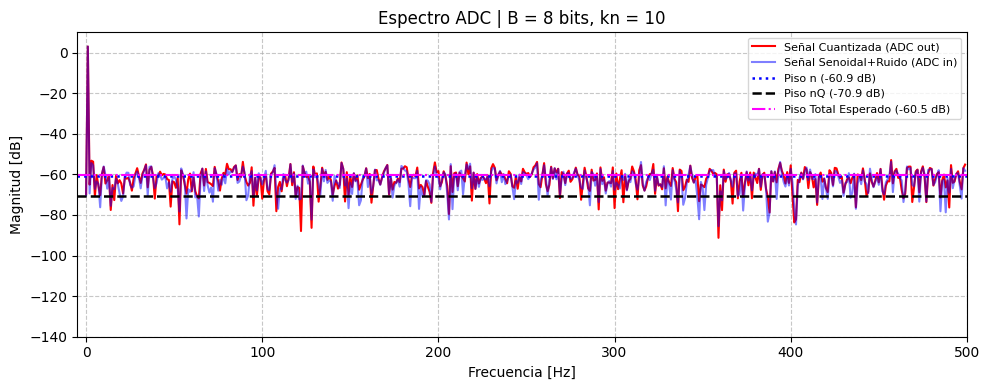

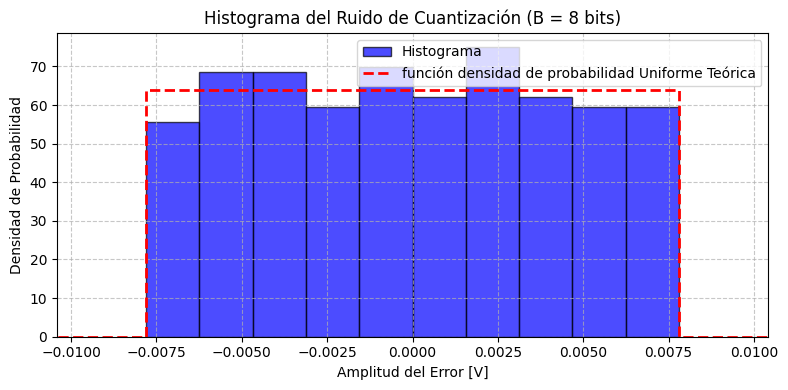

In [28]:
analizar_adc(bits=8, kn=10)

### Resultados
- **Impacto del incremento de resolución ($B = 8$ bits frente a $B = 4$ bits)**:El paso de cuantización se reduce drásticamente de $q = 0.25\text{ V}$ a $q \approx 0.0156\text{ V}$. Esto hace descender el piso de ruido de cuantización $P_q$ en aproximadamente $6.02\text{ dB}$ por cada bit adicional (~$24\text{ dB}$ por debajo respecto a $B = 4$), volviendo los escalones de discretización imperceptibles a simple vista.
- **Comportamiento según el factor $k_n$**:
  - Caso $k_n = 0.1$ ($P_n \ll P_q$): El sistema está limitado por el cuantizador. El ruido analógico de entrada se sitúa $10\text{ dB}$ por debajo del piso digital, por lo que el piso total medido a la salida coincide prácticamente con la línea de $P_q$.
  - Caso $k_n = 1$ (analizado en a): Ambas fuentes de interferencia aportan idéntica energía ($P_n = P_q$). La potencia combinada a la salida se duplica, elevando el piso total en $+3\text{ dB}$ respecto a cualquiera de los dos ruidos individuales.
  - Caso $k_n = 10$ ($P_n \gg P_q$): El sistema está limitado por el ruido analógico de entrada. Aumentar la cantidad de bits del conversor carece de efecto práctico en este régimen, dado que la cota de fondo queda dominada por el ruido exterior inyectado y no por la resolución del ADC.Evolución del histograma de error:A medida que $B$ aumenta ($8$ y $16$ bits), el error $e_q$ queda confinado a un ancho $[-q/2, q/2]$ cada vez más estrecho. Con $k_n \le 1$, la distribución del error se aproxima a la forma rectangular uniforme teórica mucho mejor que en el caso de 4 bits, donde la gran amplitud del cuanto interactúa fuertemente con la curvatura de la señal senoidal.
- **Evolución del histograma de error**:A medida que $B$ aumenta ($8$ y $16$ bits), el error $e_q$ queda confinado a un ancho $[-q/2, q/2]$ cada vez más estrecho. Con $k_n \le 1$, la distribución del error se aproxima a la forma rectangular uniforme teórica mucho mejor que en el caso de 4 bits, donde la gran amplitud del cuanto interactúa fuertemente con la curvatura de la señal senoidal.

## Conclusiones
- **Impacto de la Resolución en la Cuantización**: Se comprobó que el incremento en la cantidad de bits ($B$) reduce exponencialmente el paso de cuantización $q = \frac{2V_F}{2^B}$, lo que disminuye drásticamente la potencia del ruido digital inherente ($P_q = \frac{q^2}{12}$). En términos espectrales, cada bit adicional reduce el piso de cuantización teórico en aproximadamente $6.02\text{ dB}$, volviendo los escalones de discretización imperceptibles en el dominio temporal a partir de $B \ge 8$ bits.
- **Interacción entre Ruido Analógico y Digital ($k_n$)**:La caracterización mediante el factor de escala $k_n$ permitió evidenciar los regímenes de operación de un sistema de adquisición:
    - *Régimen dominado por el conversor ($k_n \ll 1$)*: El ruido analógico resulta despreciable frente al error de cuantización, por lo que el desempeño global está limitado exclusivamente por la resolución en bits del ADC.
    - *Régimen equilibrado ($k_n = 1$)*: Ambas fuentes aportan idéntica energía ($P_n = P_q$). Al ser procesos estocásticos incorrelados, sus varianzas se suman en potencia ($P_{total} = P_n + P_q$), lo que eleva el piso de ruido resultante medido en $+3\text{ dB}$ respecto a cada fuente individual.
    - *Régimen dominado por la interferencia de entrada ($k_n \gg 1$)*: La potencia del ruido analógico enmascara por completo el ruido del conversor. En esta condición, incrementar la resolución del ADC (e.g., pasar a 16 bits) no se traduce en una mejora del piso de ruido efectivo del sistema digitalizado, representando un sobredimensionamiento de hardware.
- **Validación Estadística del Modelo de Ruido**:El análisis mediante histogramas demostró que la aproximación clásica del error de cuantización como una variable aleatoria uniforme en $[-q/2, q/2]$ es válida siempre que la señal presente suficiente complejidad y la potencia del ruido analógico aditivo no deforme excesivamente la cota de amplitud. Cuando coexisten niveles significativos de ruido gaussiano ($k_n \ge 1$), la distribución del error total a la salida experimenta dispersión y colas que exceden el paso teórico $q$.
- **Correspondencia Teórico-Empírica en el Espectro**:Las simulaciones numéricas en Python ratificaron las fórmulas de densidad espectral calculadas para la FFT normalizada ($10 \log_{10}(4 P / N)$). Los niveles observados en los espectros bilaterales y unilaterales coincidieron con las cotas analíticas formuladas, validando el marco teórico de la conversión analógica-digital bajo presencia de ruido.